# **Exploratory Data Analysis:** Automatidata project

In [2]:
# Import packages and libraries
import numpy as np
import pandas as pd
import datetime
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load dataset into dataframe
raw_df = pd.read_csv('2017_Yellow_Taxi_Trip_Data.csv', index_col=0)
raw_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


### Task 2a. Profiling and cleaning

- Decide which columns are applicable

Given the scenario, which data columns are most applicable? 
Which data columns can I eliminate, knowing they won’t solve our problem scenario? 

- For missing & outlying data, it is always essential to first identify the type so that an effective strategy can be selected to best solving the problem at hand. 


In [4]:
raw_df.shape

(22699, 17)

In [5]:
# Explore the statistical overview of categorical data
raw_df.describe(include=object)

,tpep_pickup_datetime,tpep_dropoff_datetime,store_and_fwd_flag
count,22699,22699,22699
unique,22687,22688,2
top,07/03/2017 3:45:19 PM,10/18/2017 8:07:45 PM,N
freq,2,2,22600


In [6]:
# Explore the statistical overview of numerical data
raw_df.describe(include=np.number)

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


**Note:** Some things stand out from this table of summary statistics. For instance, there are clearly some outliers in several variables, like `tip_amount` (\$200) and `total_amount` (\$1,200). Also, a number of the variables, such as `mta_tax`, seem to be almost constant throughout the data, which would imply that they would not be expected to be very informative.

In [7]:
# Eliminate features that will not be very informative on taxi ridership
cleaned_df = raw_df.drop(columns=['mta_tax', 'improvement_surcharge',
                                  'extra', 'store_and_fwd_flag'])

# Sometimes, store_and_fwd_flag may be used to check against possible corruption of 
# datetime data when it's stored & forwarded instead of real-time record. 

In [8]:
# Check for any duplicate rows 
cleaned_df.duplicated(keep='first',
                      subset=['tpep_pickup_datetime', 'tpep_dropoff_datetime', 
                              'trip_distance', 'fare_amount']
                     ).any()

False

### Task 2b. Assess the units of measurement & data types of columns

In [9]:
# Examine the data type of each column
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22699 entries, 24870114 to 17208911
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               22699 non-null  int64  
 1   tpep_pickup_datetime   22699 non-null  object 
 2   tpep_dropoff_datetime  22699 non-null  object 
 3   passenger_count        22699 non-null  int64  
 4   trip_distance          22699 non-null  float64
 5   RatecodeID             22699 non-null  int64  
 6   PULocationID           22699 non-null  int64  
 7   DOLocationID           22699 non-null  int64  
 8   payment_type           22699 non-null  int64  
 9   fare_amount            22699 non-null  float64
 10  tip_amount             22699 non-null  float64
 11  tolls_amount           22699 non-null  float64
 12  total_amount           22699 non-null  float64
dtypes: float64(5), int64(6), object(2)
memory usage: 2.4+ MB


In [10]:
# Convert pickup & dropoff datetime columns to Datetime dtype
cleaned_df['tpep_pickup_datetime'] = pd.to_datetime(cleaned_df['tpep_pickup_datetime'], format=r'%m/%d/%Y %I:%M:%S %p') 
cleaned_df['tpep_dropoff_datetime'] = pd.to_datetime(cleaned_df['tpep_dropoff_datetime'], format=r'%m/%d/%Y %I:%M:%S %p')

# Validate the format
cleaned_df[['tpep_pickup_datetime', 'tpep_dropoff_datetime']].dtypes

tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
dtype: object

In [11]:
# Convert categorical data columns into categorical type
cate_feats = ['VendorID', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type'] 
cleaned_df[cate_feats] = cleaned_df[cate_feats].astype('category')

#### Atypical `RatecodeID` value 

In [12]:
# Examine the record(s) with unusual `RatecodeID` 
invalid_ids = cleaned_df[~cleaned_df.RatecodeID.isin([1, 2, 3, 4, 5, 6])]
invalid_ids

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,tolls_amount,total_amount
31724098,1,2017-04-18 17:47:58,2017-04-18 17:47:58,0,0.0,99,264,264,1,77.2,0.0,0.0,78.0


In [13]:
# Drop the row with global outlier in `RatecodeID` 
cleaned_df.drop(invalid_ids.index, axis=0, inplace=True)

# Validate if the invalid row is successfully removed
len(invalid_ids)


1

#### Atypical `fare_amount` values

In [14]:
# Examine the records with erroneous `fare_amount`
cleaned_df.loc[(cleaned_df.fare_amount < 0), 'payment_type'].value_counts()

# These illogical negative values were likely the refunds due to disputes (3) & unsuccessful transactions (4).
# Negative values are problematic, and therefore, will be imputed with 0.  

payment_type
3    7
4    7
1    0
2    0
Name: count, dtype: int64

In [15]:
# Impute values less than $0 with 0
cleaned_df.loc[cleaned_df.fare_amount < 0, 'fare_amount'] = 0
cleaned_df['fare_amount'].min()

0.0

#### Atypical trip_distance values

In [16]:
# Inspect the 10 unique values to determine if the 0 values in `trip_distance` are reflective of erroneous data
# or rounded values the very short trips
sorted(set(cleaned_df.trip_distance))[:10]

# As the trip distance increases incrementally across the sorted distance,
# it is very unlikely that the records are rounded values.  

[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09]

In [17]:
# Calculate the elapsed time for each trip (min) 
timelapse = cleaned_df.tpep_dropoff_datetime - cleaned_df.tpep_pickup_datetime
cleaned_df.insert(loc=3, column='trip_duration', 
                  value=round(timelapse.dt.total_seconds() / 60, 1))
cleaned_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,tolls_amount,total_amount
24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,14.1,6,3.34,1,100,231,1,13.0,2.76,0.0,16.56
35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,26.5,1,1.80,1,186,43,1,16.0,4.00,0.0,20.80
106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,7.2,1,1.00,1,262,236,1,6.5,1.45,0.0,8.75
38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,30.2,1,3.70,1,188,97,1,20.5,6.39,0.0,27.69
30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,16.7,1,4.37,1,4,112,2,16.5,0.00,0.0,17.80


In [18]:
# Inspect the records with 0 values in `trip_distance` 
untraveled = cleaned_df.loc[(cleaned_df.trip_distance == 0) \
                             & (cleaned_df.RatecodeID.isin([1, 2, 3]))]
untraveled.head()

# After carefully studying the data, it was found that the records were likely the basic charges
# for standard rate plus additional waiting time cost {1}, and fixed fare amount to airports {2, 3}
# on unattended trips.

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,tolls_amount,total_amount
52987734,1,2017-06-22 08:05:33,2017-06-22 08:05:40,0.1,1,0.0,3,231,231,2,20.0,0.0,0.0,20.3
78660848,1,2017-09-18 20:50:53,2017-09-18 20:51:03,0.2,1,0.0,1,145,145,2,2.5,0.0,0.0,3.8
83480088,1,2017-10-04 19:46:24,2017-10-04 19:46:50,0.4,1,0.0,1,132,132,2,2.5,0.0,0.0,4.3
14024301,1,2017-02-22 04:01:44,2017-02-22 04:01:53,0.2,1,0.0,1,90,90,3,2.5,0.0,0.0,3.8
3767951,1,2017-01-14 07:00:26,2017-01-14 07:00:53,0.4,1,0.0,1,208,208,1,2.5,6.7,0.0,10.0


In [19]:
# Examine the size of records with 0 value in `trip_distance`
len(cleaned_df.loc[(cleaned_df.trip_distance == 0)])

# Since there's only a small fraction of the records posing a zero-value problem, 
# it's very unlikely for the data to affect the overall data story.
# Therefore, the `trip_distance` column will remain untouched with regard to outliers.

147

#### Atypical `passenger_count` values

In [20]:
# Examine the size of records with 0 value in `passenger_count`
len(cleaned_df.loc[(cleaned_df.passenger_count == 0)])

# Similarly, we may choose to drop or simply leave the 0-values `passenger_count` here. 

32

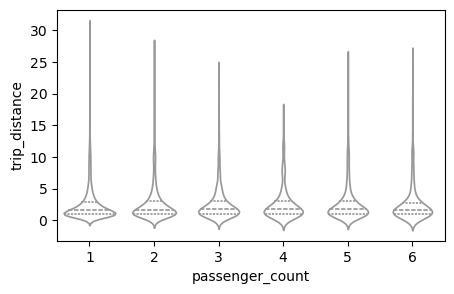

In [21]:
attending_pass = cleaned_df[(cleaned_df.passenger_count != 0) \
                             & (cleaned_df.RatecodeID == 1)]

fig = plt.subplots(figsize=(5, 3))
ax = sns.violinplot(data=attending_pass, x='passenger_count', y='trip_distance',
                    inner='quartile', color='white')

# Provided that the `passenger_count` were driver-entered values and we're no way
# in distinguishing the significant pattern from other variables besides credit card payment, 
# we'll impute the 0-values with the mode that came closest. 

In [22]:
# Impute values with the mode of `passenger_count`
cleaned_df.loc[cleaned_df.passenger_count == 0, 'passenger_count'] = 1

# Validate if the imputation is successfully conducted
cleaned_df.passenger_count.isin([0]).any()

False

In [23]:
# Save the cleaned dataset: 
cleaned_df.to_csv('Clean_2017_Taxi_Trip_data.csv', index=True)

### Task 3. Data visualization

### Boxplots

**trip distance**

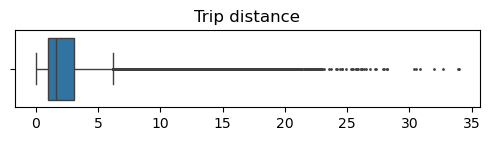

In [24]:
# Create box plot of trip_distance
plt.figure(figsize=(6, 1))
sns.boxplot(x=cleaned_df['trip_distance'], fliersize=1)
plt.title('Trip distance')
plt.xlabel('')
plt.show()

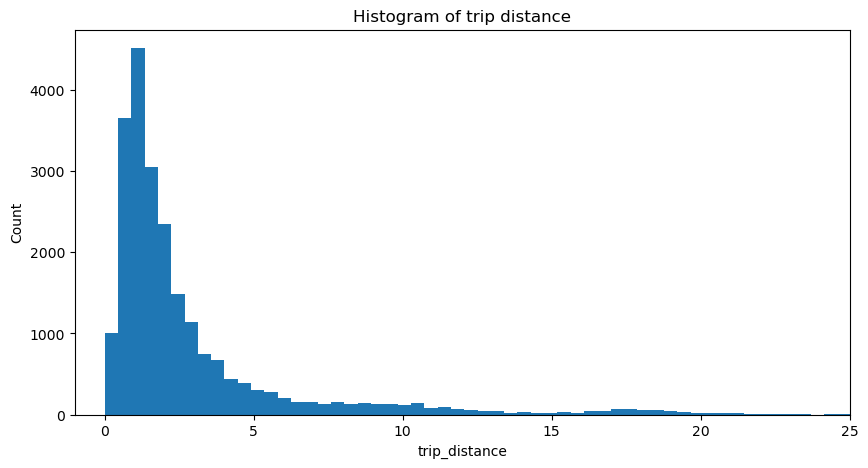

[0.         0.44684211 0.89368421 1.34052632 1.78736842]


In [25]:
# Create histogram of trip_distance
# ('scott' bins estimator is less robust but it takes into account the data variability & data size) 
fig = plt.subplots(figsize=(10, 5))
trip_counts, trip_edges = np.histogram(cleaned_df['trip_distance'], bins='scott')
trip_hist = cleaned_df['trip_distance'].plot(kind='hist', bins=trip_edges)
trip_hist.set(title='Histogram of trip distance', xlim=(-1, 25),
              xlabel='trip_distance', ylabel='Count')
plt.show()
print(trip_edges[:5])

- The majority of trips were relatively short journeys with less than 2 miles. 
The no. of trips decays exponentially as the distance traveled increases beyond 2 miles. 

**total amount**

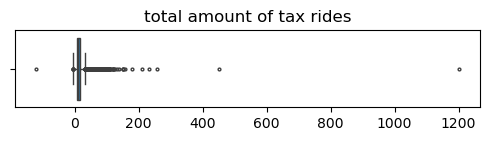

In [26]:
# Create box plot of total_amount
plt.figure(figsize=(6, 1))
fare_box = sns.boxplot(x="total_amount", data=cleaned_df, fliersize=2)
fare_box.set(title='total amount of tax rides', xlabel='')
plt.show()

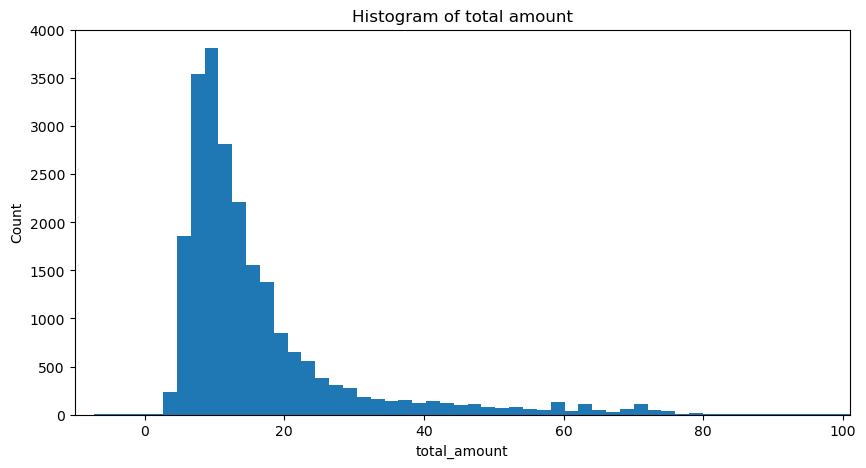

[0.6549399399399363, 2.6378078078078033, 4.62067567567567, 6.6035435435435375, 8.586411411411419, 10.569279279279286, 12.552147147147153, 14.53501501501502, 16.517882882882887, 18.500750750750754]


In [27]:
# Create histogram of fare_amount
fig = plt.subplots(figsize=(10, 5))
tot_counts, tot_edges = np.histogram(cleaned_df.total_amount, bins='scott')
total_hist = cleaned_df.total_amount.plot(kind='hist', bins=tot_edges)
total_hist.set(title='Histogram of total amount', xlim=(-10, 101),
              xlabel='total_amount', ylabel='Count')
plt.show()
print([i for i in tot_edges if i > 0][:10])

- The total cost for each trip also has a distribution that skews right, with
most riders spending roughly $5-15.

**tip amount**

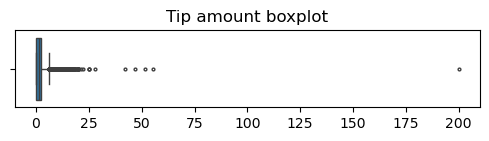

In [28]:
# Create box plot of tip_amount
plt.figure(figsize=(6,1))
tip_box = sns.boxplot(x='tip_amount', data=cleaned_df, fliersize=2)
tip_box.set(title='Tip amount boxplot', xlabel='')
plt.show()

In [29]:
cleaned_df.loc[cleaned_df.payment_type == 2, 'tip_amount'].describe()

count    7267.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: tip_amount, dtype: float64

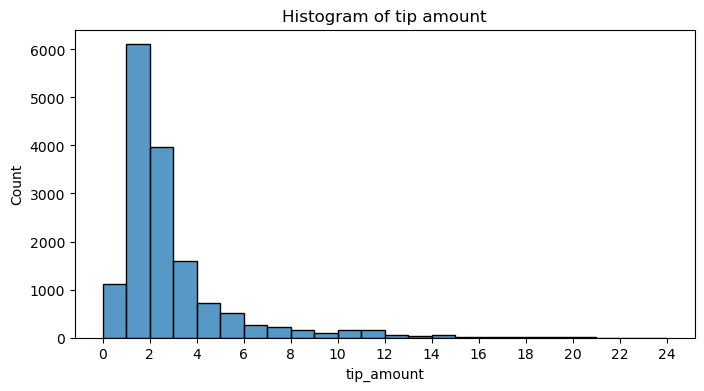

In [30]:
# Only the credit tips are considered here to prevent the huge no. of zero-value 
# tips from cash payments from skewing the result.

# Create histogram of tip_amount
credit_tip = cleaned_df[cleaned_df.payment_type == 1]

plt.figure(figsize=(8, 4))
hist_tip = sns.histplot(data=credit_tip, x='tip_amount', bins=range(0, 25, 1))
hist_tip.set(title='Histogram of tip amount', xticks=range(0, 25, 2))
plt.show()

- The credit tip amount is right-skewed, with most riders paying around $1-3. 

**tip_amount by vendor**

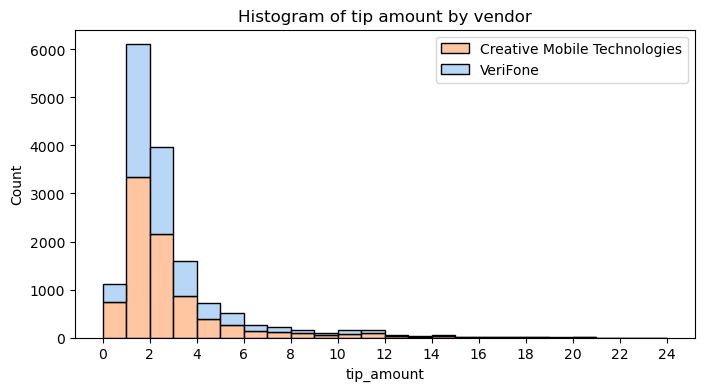

In [31]:
# Create histogram of tip_amount by vendor
fig = plt.figure(figsize=(8, 4))
tip_by_vendor = sns.histplot(x='tip_amount', hue='VendorID', data=credit_tip,
                             bins=range(0,25,1), palette='pastel', 
                             multiple='stack', legend=True)
tip_by_vendor.set(title='Histogram of tip amount by vendor',
                  xticks=range(0, 25, 2))
tip_by_vendor.legend(['Creative Mobile Technologies', 'VeriFone'])
plt.show()

- Separating the tip amount by vendor reveals that there are no noticeable 
aberrations in the distribution of tips btw the two vendors. 

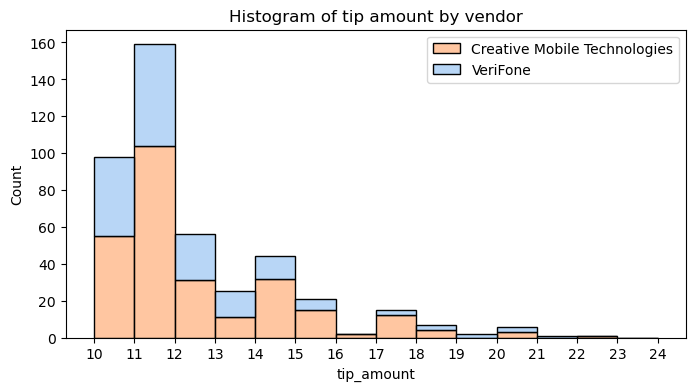

In [32]:
# Zoom in on the upper end of the range of tips to check whether one of the
# vendor gets noticeably more of the most generous tips.

# Create histogram of tip_amount by vendor for tips > $10 
plt.figure(figsize=(8, 4))
toptip = credit_tip.loc[credit_tip.tip_amount > 10, ['tip_amount', 'VendorID']]

toptip_by_vendor = sns.histplot(x='tip_amount', hue='VendorID',
                                data=toptip, bins=range(10, 25, 1),
                                multiple='stack', palette='pastel')
toptip_by_vendor.set(title='Histogram of tip amount by vendor',
                     xticks=range(10, 25, 1))
toptip_by_vendor.legend(['Creative Mobile Technologies', 'VeriFone'])
plt.show()

- The proportions are maintained even at these higher tip amounts, 
with the exception being at highest extremity, but this is not noteworthy due to the low sample size at these tip amounts.

**Mean tips by passenger count**

In [33]:
# Calculate mean tips by passenger_count
meantip_by_passenger = (cleaned_df[['passenger_count', 'tip_amount']]
                        .groupby(by='passenger_count')
                        .mean())
meantip_by_passenger

,tip_amount
passenger_count,
1,1.849621
2,1.856378
3,1.716768
4,1.530264
5,1.873185
6,1.720260


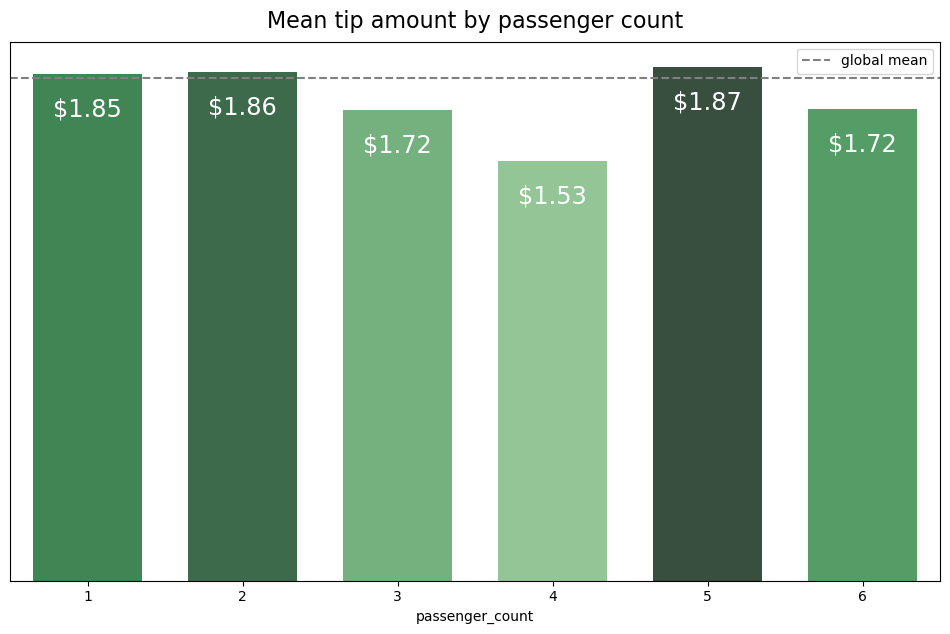

In [34]:
# Create bar plot for mean tips by passenger count
plt.figure(figsize=(12, 7))
pal = sns.color_palette('Greens_d', cleaned_df.passenger_count.nunique()) # discrete color
rank = meantip_by_passenger.tip_amount.argsort().argsort() # sort indexes based on values
p = sns.barplot(x=meantip_by_passenger.index,     
                y=meantip_by_passenger.tip_amount,
                palette=np.array(pal)[rank],
                width=0.7)

for rect in p.patches:
    p.annotate('$' + str(round(rect.get_height(), 2)),
               (rect.get_x() + rect.get_width() / 2., rect.get_height() + 0.06),
                ha='center', va='bottom', xytext=(0, -46), color='w',
                textcoords='offset points', fontsize='xx-large')
p.axhline(cleaned_df.tip_amount.mean(), ls='--', color='grey', label='global mean')
p.legend(loc='upper right')
p.set_title('Mean tip amount by passenger count', fontsize=16, y=1.01)
p.set(ylabel='', yticks=[] , yticklabels='')
plt.show()

- The mean tip amount varies very little by passenger count. Although it does drop noticeably for 4-passenger rides, it's expected that there would be a higher degree of fluctuation because rides with 4-passengers were the least plentiful in dataset.

**Plot  by hour of the day**

This is often valuable, as it allows us to examine the traffic conditions throughout the day.

In [35]:
# Create a month column
cleaned_df['Month_txt'] = cleaned_df.tpep_pickup_datetime.dt.month_name().str.slice(stop=3)

# Create a day of week column
cleaned_df['Day'] = cleaned_df.tpep_pickup_datetime.dt.strftime('%a')

# Create a hour of day column
cleaned_df['Hour'] = cleaned_df.tpep_pickup_datetime.dt.strftime('%#H')

cleaned_df[['Month_txt', 'Day', 'Hour']].tail()

,Month_txt,Day,Hour
14873857,Feb,Fri,17
66632549,Aug,Sun,16
74239933,Sep,Mon,14
60217333,Jul,Sat,12
17208911,Mar,Thu,13


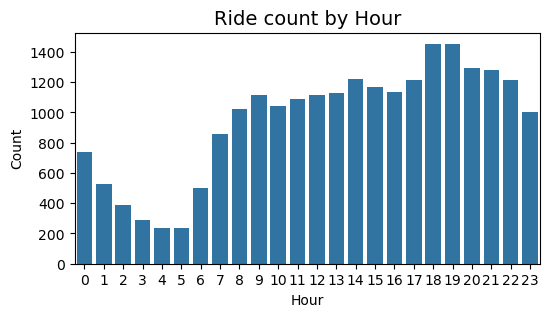

In [36]:
# Create a plot of the no. of rides by hour
plt.figure(figsize=(6, 3))
traffic_hour_ax = sns.countplot(x=cleaned_df.Hour, order=range(0, 24, 1))
traffic_hour_ax.set(xlabel='Hour', ylabel='Count')
traffic_hour_ax.set_title('Ride count by Hour', fontsize=14)
plt.show()

- The demand for a taxi ride stays relatively constant during the time of working hours, and grows significantly as soon as it approaches the off-duty hours with the highest at 6pm and 7pm. <br>
- However, the no. of traffic starts reducing past the peak hour, and it is roughly 30% lower than the period of working hours after midnight.

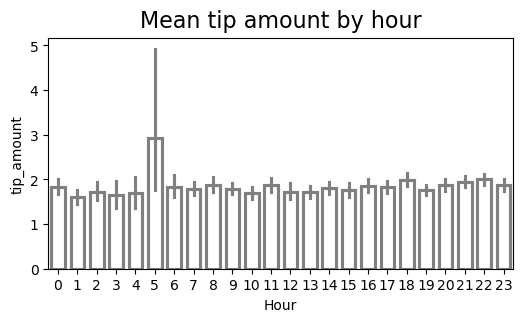

In [37]:
# Create a bar plot of mean tip by hour
plt.figure(figsize=(6, 3))
bar_tip_by_hr = sns.barplot(x='Hour', y='tip_amount', data=cleaned_df,
                            order=range(0, 24, 1), estimator='mean', 
                            fill=False, color='grey', width=0.7)
bar_tip_by_hr.set_title('Mean tip amount by hour', fontsize=14, y=1.01)
plt.show()

- The tip amounts are fairly consistent throughout the day, except for 5 o'clock in the morning. Riders who go to work early at this hour tend to tip better probably because it's harder to get a taxi with generally lesser no. of taxi on the street. 

**Plot total ride count by month**

In [38]:
# Get total number of rides for each month
month_rides = (cleaned_df[['VendorID', 'Month_txt']].groupby(by='Month_txt', as_index=False)
               .agg(Count = pd.NamedAgg(column='VendorID', aggfunc='count')))

# Reorder the monthly ride list so months go in order
month_ord = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
             'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_rides['Month_txt'] = pd.Categorical(month_rides.Month_txt,
                                          categories=month_ord, 
                                          ordered=True)
month_rides.sort_values('Month_txt', ignore_index=True)


,Month_txt,Count
0,Jan,1997
1,Feb,1769
2,Mar,2049
3,Apr,2018
4,May,2013
5,Jun,1964
6,Jul,1697
7,Aug,1724
8,Sep,1734
9,Oct,2027


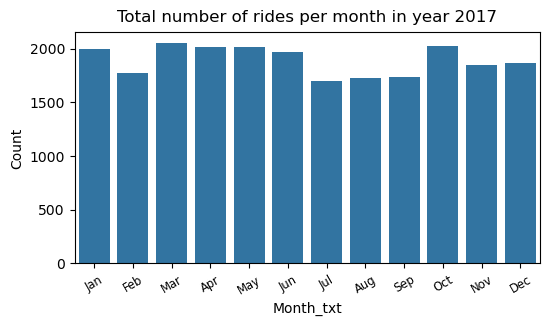

In [39]:
# Create a bar plot of total rides per month
plt.figure(figsize=(6, 3))
bar_month = sns.barplot(data=month_rides, x='Month_txt', 
                        y='Count', order=month_ord)
bar_month.set_title('Total number of rides per month in year 2017', y=1.01)
bar_month.tick_params(axis='x', labelrotation=30, labelsize='small')
plt.show()

- Monthly rides are fairly consistent, with notable dips in summer months of 
July, August, and September, and also in February.  

**Plot total ride count by day**

In [40]:
# Create a bar plot of total rides per day
day_rides = (cleaned_df[['VendorID', 'Day']].groupby(by='Day', as_index=False)
             .agg(Count = pd.NamedAgg(column='VendorID', aggfunc='count')))

day_ord = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_rides['Day'] = pd.Categorical(day_rides.Day, categories=day_ord, ordered=True)
day_rides.sort_values('Day', ignore_index=True)

,Day,Count
0,Mon,2931
1,Tue,3197
2,Wed,3390
3,Thu,3402
4,Fri,3413
5,Sat,3367
6,Sun,2998


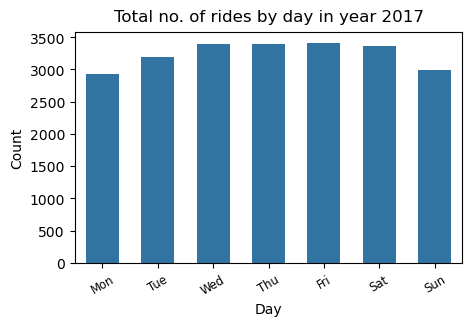

In [41]:
# Create bar plot for ride count by day
plt.figure(figsize=(5, 3))
bar_day = sns.barplot(data=day_rides, x='Day', y='Count',
                      order=day_ord, width=0.6)
bar_day.set_title("Total no. of rides by day in year 2017", y=1.01)
bar_day.tick_params(axis='x', labelrotation=30, labelsize='small')
plt.show()

Suprisingly, Wednesday through Saturday had the highest no. of daily rides, 
while Sunday & Monday had the least. 
Probably because people prefer to drive during their leisure day and the first day of work. 

**Plot total revenue by day of the week**

In [42]:
# Create a bar plot for total revenue by day
day_revenue = (cleaned_df.loc[cleaned_df.total_amount > 0, ['Day', 'total_amount']]
               .groupby('Day', as_index=False).sum())

day_ord = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_revenue['Day'] = pd.Categorical(day_revenue.Day, categories=day_ord, ordered=True)
day_revenue.sort_values('Day', ignore_index=True)

,Day,total_amount
0,Mon,49582.47
1,Tue,52452.94
2,Wed,55317.57
3,Thu,57190.51
4,Fri,55830.34
5,Sat,51325.30
6,Sun,48634.66


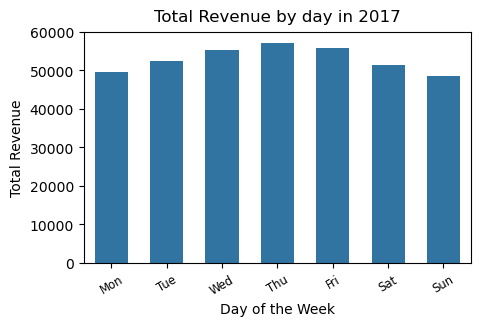

In [43]:
# Create a bar plot of total revenue by day
plt.figure(figsize=(5,3))
bar_dayrevenue = sns.barplot(data=day_revenue, x='Day', 
                             y='total_amount (USD)', width=0.6)
bar_dayrevenue.set_title('Total Revenue by day in 2017', y=1.01)
bar_dayrevenue.set(xlabel='Day of the Week', ylabel='Total Revenue')
bar_dayrevenue.tick_params(axis='x', labelrotation=30, labelsize='small')
plt.show()

- Thursday had the highest gross revenue of all days, and Sunday & Monday
had the least. Interestingly, although Saturday had only 35 fewer rides than
Thursday, its gross revenue was ~$6,000 less than Thursday's —more than 10% drop.

**Plot total revenue by month**

In [44]:
# Create a table with breakdown of the taxi's revenue by month 
month_df = cleaned_df.loc[cleaned_df.total_amount > 0,
                          ['Month_txt', 'tip_amount', 'total_amount']]
monthly_revenue = month_df.groupby('Month_txt', as_index=False).sum()
monthly_revenue['Pct of tip'] = round(monthly_revenue.tip_amount / monthly_revenue.total_amount * 100, 2)

month_ord = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
             'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_revenue['Month_txt'] = pd.Categorical(monthly_revenue.Month_txt, categories=month_ord, ordered=True)
monthly_revenue.sort_values('Month_txt', ignore_index=True)

,Month_txt,tip_amount,total_amount,Pct of tip
0,Jan,3574.85,31739.05,11.26
1,Feb,3422.28,28943.69,11.82
2,Mar,3708.97,33091.69,11.21
3,Apr,3594.32,32059.14,11.21
4,May,3912.94,33832.38,11.57
5,Jun,3611.85,32924.82,10.97
6,Jul,2811.47,26626.24,10.56
7,Aug,2955.44,27759.56,10.65
8,Sep,3133.24,28211.18,11.11
9,Oct,3747.43,33070.63,11.33


- The proportions of tip received are fairly consistent, and they occupy roughly 10-12% of the drivers' revenue.

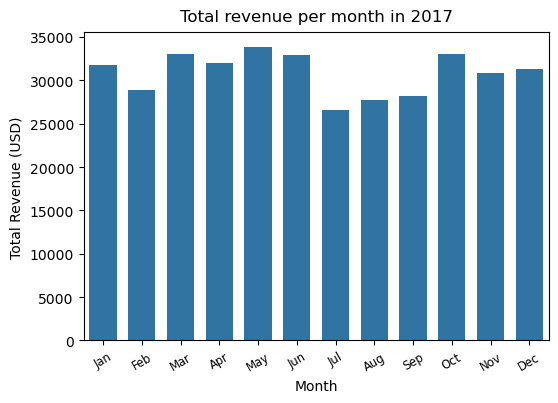

In [45]:
# Create a bar plot of total revenue by month
plt.figure(figsize=(6, 4))
bar_month_revenue = sns.barplot(data=monthly_revenue, 
                                x='Month_txt',
                                y='total_amount',
                                width=0.7)
bar_month_revenue.tick_params(axis='x', labelrotation=30, labelsize='small')
plt.title('Total revenue per month in 2017', y=1.01)
plt.xlabel('Month'); plt.ylabel('Total Revenue (USD)')
plt.show()

- As expected, the monthly revenue generally follows the pattern of monthly rides, with lower revenue in the summer months of July, August, and September, and also one in February.

#### Scatter plot

**Plot tip amount against trip distance**

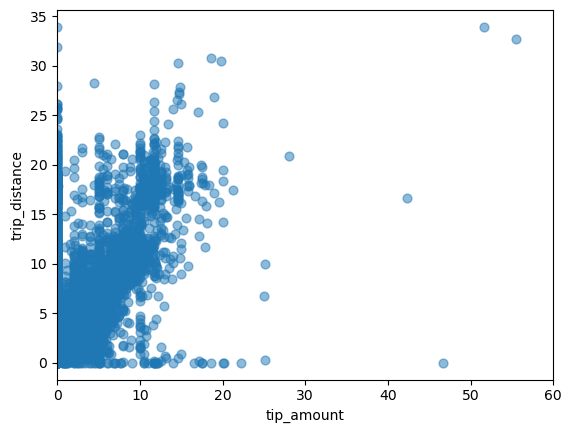

In [46]:
tip_by_dist= cleaned_df.plot.scatter(x='tip_amount', y='trip_distance', 
                                     fc=None, s=40, alpha=0.5)
tip_by_dist.set(xlim=(0,60))
plt.show()

- Although it might not be substantial, most of the customers are inclined to pay a comparatively larger amount of tip when they're traveling for a longer distance. 

**Plot mean trip distance by drop-off location**

In [47]:
# Get the number of unique drop-off location IDs
cleaned_df.DOLocationID.nunique()

216

In [48]:
# For a reliable result, only the attended rides with `trip_distance` > 0 are accounted
rides = cleaned_df.loc[cleaned_df.trip_distance > 0]

# Calculate the mean trip distance for each drop-off location
DO_by_distance = (rides[['trip_distance', 'DOLocationID']]
                  .groupby('DOLocationID', as_index=False)
                  .agg(avg_distance = pd.NamedAgg(column='trip_distance', aggfunc='mean'))) 

# Sort the results in descending order by mean trip distance
DO_by_distance.sort_values('avg_distance', ascending=False)

,DOLocationID,avg_distance
16,23,24.275000
21,29,21.650000
167,210,20.500000
0,1,18.091562
5,11,17.945000
...,...,...
83,100,1.831615
109,137,1.823836
189,234,1.730424
192,237,1.557546


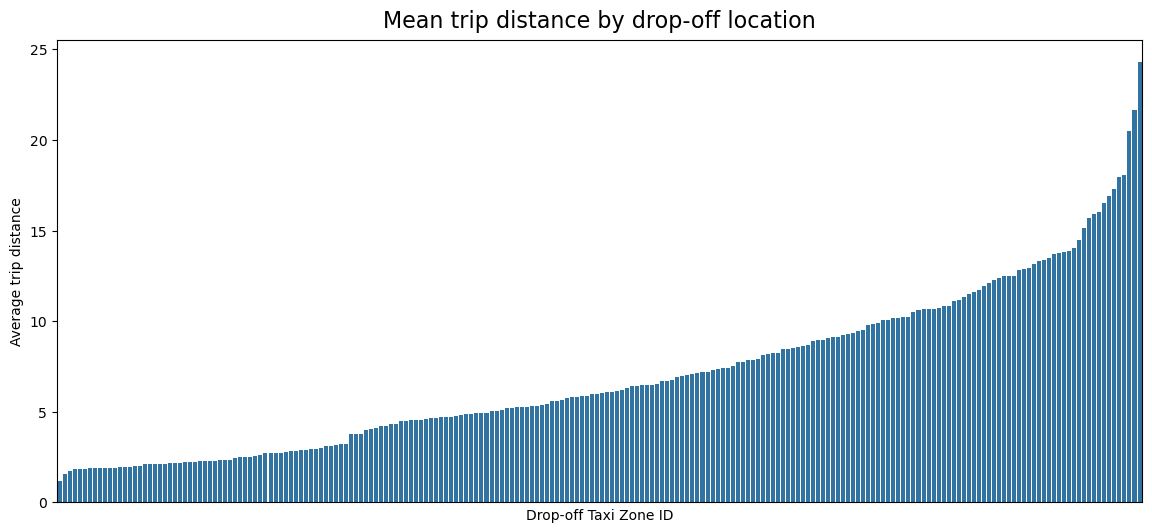

In [49]:
# Create a bar plot of mean trip distances by drop-off location in ascending order of distance
fig = plt.figure(figsize=(14, 6))
bar_DO_by_dist = sns.barplot(data=DO_by_distance, 
                             x='DOLocationID', 
                             y='avg_distance', 
                             order=DO_by_distance.sort_values('avg_distance').DOLocationID)
bar_DO_by_dist.set(xlabel='Drop-off Taxi Zone ID',
                   ylabel='Average trip distance',
                   xticks=[], xticklabels='')
bar_DO_by_dist.set_title('Mean trip distance by drop-off location',
                         fontsize=16, y=1.01)
plt.show()

- This plot presents a characteristic curve related to the cumulative density function of a normal distribution. In other words, it indicates that the drop-off points are relatively evenly distributed over the terrain.

**Histogram of rides by drop-off location**

In [50]:
# Check if all drop-off locations are consecutively numbered
DO_numbers = cleaned_df['DOLocationID'].astype('int64')
missing_IDs = DO_numbers.max() - DO_numbers.nunique()

print(f'Sorted list IDs\t: {sorted(set(DO_numbers))[:15]}\n\
No. of missing\t: {missing_IDs}')

Sorted list IDs	: [1, 4, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21]
No. of missing	: 49


*There are 49 missing numbers in the consecutively numbered drop-off location IDs.* 

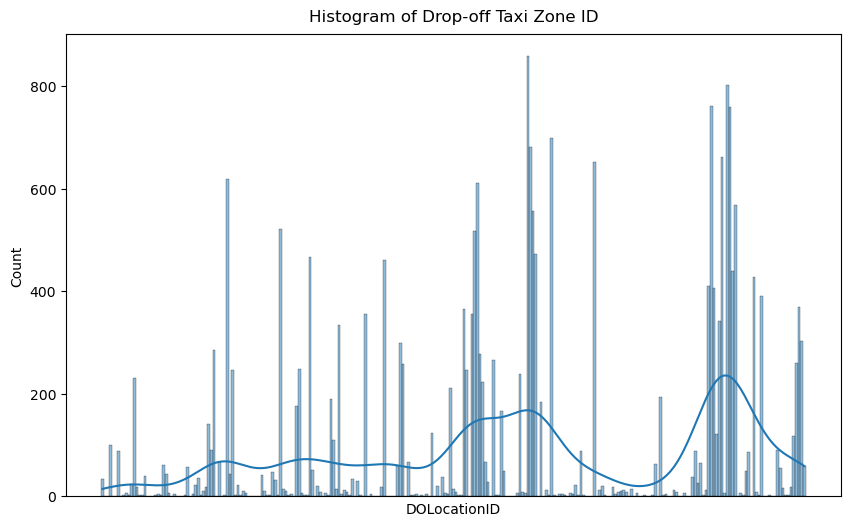

In [51]:
plt.figure(figsize=(10, 6))
hist_DOLoc = sns.histplot(x=cleaned_df['DOLocationID'],
                          discrete=True, kde=True)
plt.title('Histogram of Drop-off Taxi Zone ID', y=1.01)
plt.xticks(ticks=[], labels='')
plt.show()

- Notice that out of the 200+ drop-off locations, a disporportionate number of locations receive the majority of the traffic, while all all the rest get relatively few trips.

- It is likely that these high-traffic locations are near popular tourist attractions like the Empire State Building or Time Square, airports, and train and bus terminals. <br>
( To be sure, it is helpful to know what each ID correspond with. Unfortunately, this is not in the data )